<a href="https://colab.research.google.com/github/Hala-sala7/chicago-crime-analysis/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Data — Time Series Analysis
**Portfolio Project 3 — Part 1**

This notebook prepares the Chicago crime dataset (2001–present) for time series
analysis and answers stakeholder questions for a local newspaper reporter
about crime trends in Chicago.

**Original source:** Chicago Data Portal — Crimes 2001 to Present.

## 1. Imports & Setup
Import the libraries used throughout the notebook and configure plotting defaults.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile, glob, os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

## 2. Mount Google Drive
Connect Google Drive so we can access the zipped dataset stored there.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Locate the Zip File
Search Drive for the dataset zip and print its full path.

In [5]:
glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)

['/content/drive/MyDrive/assignment.zip',
 '/content/drive/MyDrive/Chicago_Crime_2001-2022.zip']

## 4. Extract the Data
Unzip the dataset (one CSV per year) into a local `/content/Data` folder.
Note: this folder is temporary in Colab — re-run this cell after a restart.

In [9]:
zip_path = "/content/drive/MyDrive/Chicago_Crime_2001-2022.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/Data')

print("Done. Folder contents:")
print(os.listdir('/content/Data'))

Done. Folder contents:
['Data']


## 5. Locate the CSV Files
The dataset is split into one CSV per year. Find them all (recursively).
The README file is automatically ignored because we only match `*.csv`.

In [10]:
csv_files = sorted(glob.glob('/content/Data/**/*.csv', recursive=True))
print(f"Found {len(csv_files)} files:")
for f in csv_files:
    print("  -", f)

Found 22 files:
  - /content/Data/Data/Chicago-Crime_2001.csv
  - /content/Data/Data/Chicago-Crime_2002.csv
  - /content/Data/Data/Chicago-Crime_2003.csv
  - /content/Data/Data/Chicago-Crime_2004.csv
  - /content/Data/Data/Chicago-Crime_2005.csv
  - /content/Data/Data/Chicago-Crime_2006.csv
  - /content/Data/Data/Chicago-Crime_2007.csv
  - /content/Data/Data/Chicago-Crime_2008.csv
  - /content/Data/Data/Chicago-Crime_2009.csv
  - /content/Data/Data/Chicago-Crime_2010.csv
  - /content/Data/Data/Chicago-Crime_2011.csv
  - /content/Data/Data/Chicago-Crime_2012.csv
  - /content/Data/Data/Chicago-Crime_2013.csv
  - /content/Data/Data/Chicago-Crime_2014.csv
  - /content/Data/Data/Chicago-Crime_2015.csv
  - /content/Data/Data/Chicago-Crime_2016.csv
  - /content/Data/Data/Chicago-Crime_2017.csv
  - /content/Data/Data/Chicago-Crime_2018.csv
  - /content/Data/Data/Chicago-Crime_2019.csv
  - /content/Data/Data/Chicago-Crime_2020.csv
  - /content/Data/Data/Chicago-Crime_2021.csv
  - /content/Data/

## 6. Inspect the Columns
Read just the first file to confirm the column names (especially the date column)
before loading everything.

In [11]:
sample = pd.read_csv(csv_files[0], nrows=5)
print(sample.columns.tolist())
sample

['ID', 'Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Latitude', 'Longitude']


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


## 7. Combine All Years into One DataFrame
Read every yearly file (keeping only the columns we need) and concatenate them.

In [12]:
use_cols = ['Date', 'Primary Type', 'Description', 'District', 'Arrest', 'Domestic']

df = pd.concat(
    [pd.read_csv(f, usecols=use_cols) for f in csv_files],
    ignore_index=True
)
print("Shape:", df.shape)
df.head()

Shape: (7713109, 6)


,Date,Primary Type,Description,Arrest,Domestic,District
0,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,False,False,16.0
1,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,False,True,8.0
2,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,True,False,3.0
3,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,False,False,24.0
4,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,False,True,2.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   Date          object 
 1   Primary Type  object 
 2   Description   object 
 3   Arrest        bool   
 4   Domestic      bool   
 5   District      float64
dtypes: bool(2), float64(1), object(3)
memory usage: 250.1+ MB


## 8. Convert the Date Column to Datetime
Convert the `Date` text column to a proper datetime type for time series analysis.

In [14]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')
df['Date'].head()

,Date
0,2001-01-01 01:00:00
1,2001-01-01 13:00:00
2,2001-01-01 13:00:00
3,2001-01-01 01:00:00
4,2001-01-01 01:00:00


## 9. Set Datetime Index
Set `Date` as the index and sort chronologically.
**(Form 1 of the data: each row = 1 crime, datetime index.)**

In [15]:
df = df.set_index('Date').sort_index()
df.head()

,Primary Type,Description,Arrest,Domestic,District
Date,,,,,
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,22.0
2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,False,False,8.0
2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,False,False,2.0
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,9.0
2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,False,False,10.0


## 10. Clean the Data
Check missing values and drop rows missing `District`
(needed later for the district comparison).

In [17]:
df.isna().sum()

,0
Primary Type,0
Description,0
Arrest,0
Domestic,0
District,47


In [18]:
print("Missing District:", df['District'].isna().sum())
print("Percentage:", round(df['District'].isna().mean() * 100, 4), "%")

Missing District: 47
Percentage: 0.0006 %


Only **47 rows** (0.0006% of the data) are missing a `District`.
Since this is a negligible fraction and `District` is a categorical
identifier (imputing a fake district would distort the district analysis),
we drop these rows.

In [19]:
df = df.dropna(subset=['District'])
df['District'] = df['District'].astype(int)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7713062, 5)


## 11. Resampled Daily Crime Counts
Create the second form of the data: each row = 1 day with the total number
of crimes. Used for trend & seasonality analysis.

In [20]:
daily_counts = df.resample('D').size().rename('Crime_Count')
daily_counts.head()

,Crime_Count
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


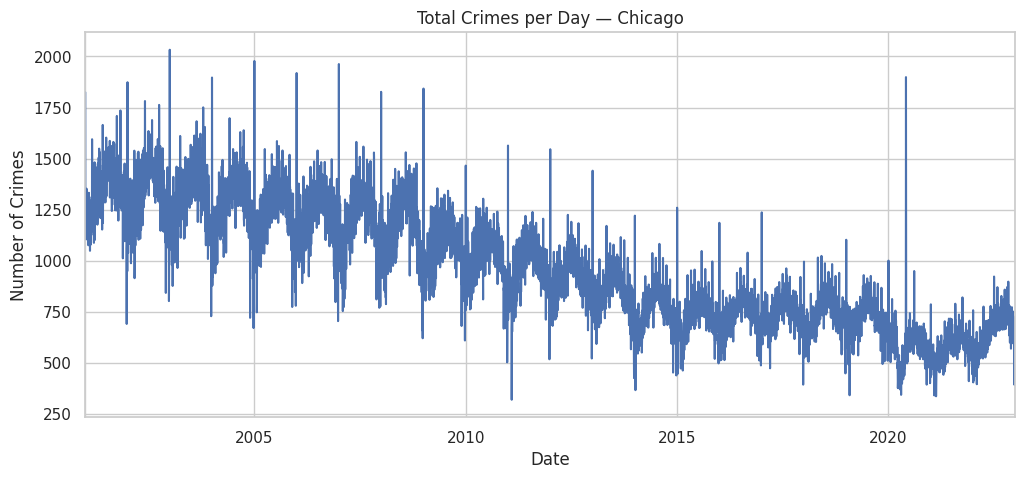

In [21]:
daily_counts.plot(title='Total Crimes per Day — Chicago')
plt.ylabel('Number of Crimes')
plt.show()

### Observations — Daily Crime Counts (2001–2022)

- **Clear downward trend:** Daily crimes fell from ~1,200–1,500/day in the early
  2000s to ~600–800/day by the early 2020s — almost a 50% decline over two decades.
- **Strong seasonality:** A repeating yearly wave is visible (crime peaks in summer,
  dips in winter), which we will confirm later with seasonal decomposition.
- **Sharp spikes on Jan 1st:** The recurring tall spikes (e.g. the first point = 1,825)
  fall on January 1st. This is a known data artifact — crimes with an unknown exact
  date are logged as Jan 1st, inflating that day.
- **2020 dip:** The unusually low values around 2020 line up with COVID-19 lockdowns.

## 12. Feature Engineering
Add a `Holiday` column (holiday name if the date is a US holiday, else NaN)
plus helper time columns (Year, Month, Hour, Day name) for the analysis section.

In [22]:
!pip install holidays -q
import holidays

years = df.index.year.unique().tolist()
us_holidays = holidays.US(years=years)

df['Holiday']    = df.index.normalize().map(lambda d: us_holidays.get(d))
df['Year']       = df.index.year
df['Month']      = df.index.month
df['Month_Name'] = df.index.month_name()
df['Hour']       = df.index.hour
df['Day_Name']   = df.index.day_name()

df.head()

,Primary Type,Description,Arrest,Domestic,District,Holiday,Year,Month,Month_Name,Hour,Day_Name
Date,,,,,,,,,,,
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,22,New Year's Day,2001,1,January,0,Monday
2001-01-01,THEFT,AGG: FINANCIAL ID THEFT,False,False,8,New Year's Day,2001,1,January,0,Monday
2001-01-01,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,False,False,2,New Year's Day,2001,1,January,0,Monday
2001-01-01,THEFT,FINANCIAL ID THEFT: OVER $300,False,False,9,New Year's Day,2001,1,January,0,Monday
2001-01-01,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,False,False,10,New Year's Day,2001,1,January,0,Monday


# Topic 2 — Crimes Across the Years

**Stakeholder questions:**
1. Is the total number of crimes increasing or decreasing across the years?
2. Are there individual crimes doing the opposite of the overall trend?

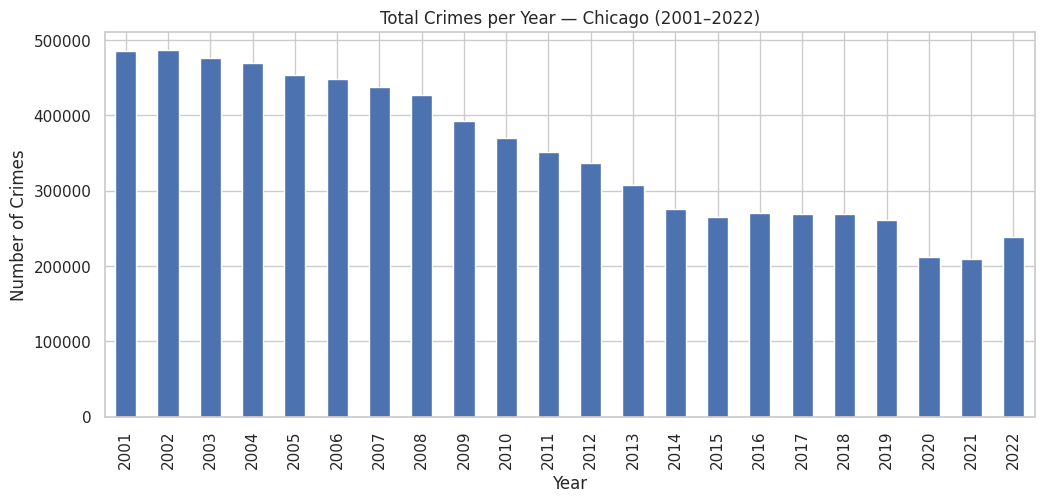

,count
Year,
2001,485886
2002,486807
2003,475985
2004,469420
2005,453772
2006,448178
2007,437085
2008,427143
2009,392827


In [23]:
yearly = df['Year'].value_counts().sort_index()

yearly.plot(kind='bar', title='Total Crimes per Year — Chicago (2001–2022)')
plt.ylabel('Number of Crimes')
plt.xlabel('Year')
plt.show()

yearly

### Answer (Q1): Is total crime increasing or decreasing?

**Total crime is clearly decreasing across the years.**

- 2001: **485,886** crimes → 2022: **238,858** crimes
- A decline of about **51%** over the two decades.
- The drop is steady from 2001–2014, then levels off around 260,000–270,000/year.
- **2020 (212,194)** and **2021 (208,824)** are the two lowest years, lining up
  with the COVID-19 pandemic, followed by a partial rebound in 2022.

In [24]:
# Crimes per type per year
type_year = df.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)

# Focus on reasonably common crimes (avoid noise from rare types)
common = type_year.columns[type_year.sum() > 5000]
ty = type_year[common]

In [25]:
# % change: average of last 3 years vs first 3 years
early  = ty.iloc[:3].mean()
recent = ty.iloc[-3:].mean()
pct_change = ((recent - early) / early * 100).round(1).sort_values(ascending=False)

In [26]:
print("Crimes that INCREASED the most (against the overall trend):")
print(pct_change.head(5))
print("\nCrimes that DECREASED the most:")
print(pct_change.tail(5))

Crimes that INCREASED the most (against the overall trend):
Primary Type
CRIMINAL SEXUAL ASSAULT             4254.6
WEAPONS VIOLATION                    105.0
DECEPTIVE PRACTICE                    23.7
HOMICIDE                              20.8
INTERFERENCE WITH PUBLIC OFFICER      15.6
dtype: float64

Crimes that DECREASED the most:
Primary Type
LIQUOR LAW VIOLATION   -87.8
NARCOTICS              -88.8
PROSTITUTION           -96.5
GAMBLING               -98.4
CRIM SEXUAL ASSAULT    -98.5
dtype: float64


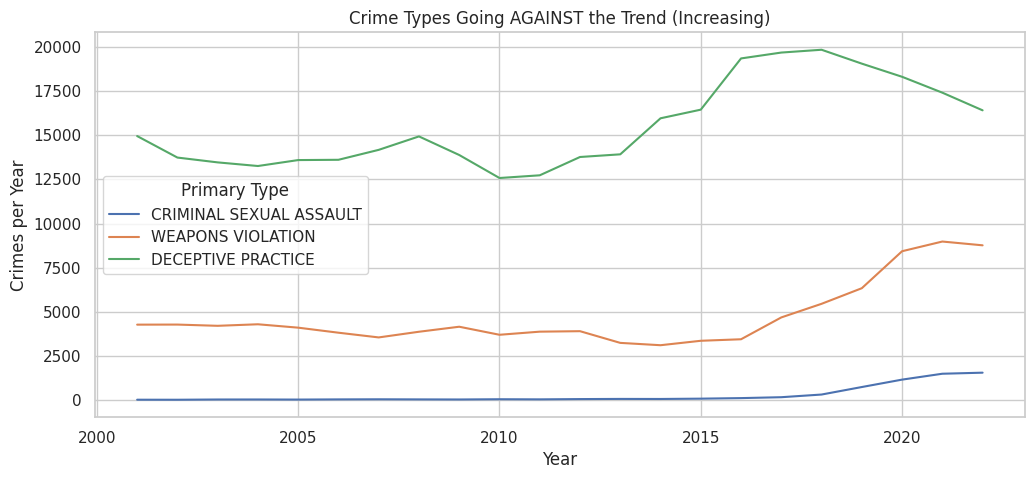

In [27]:
increasing = pct_change.head(3).index
ty[increasing].plot(title='Crime Types Going AGAINST the Trend (Increasing)')
plt.ylabel('Crimes per Year')
plt.show()

### Answer (Q2): Are there crimes going against the overall trend?

**Yes.** While total crime fell ~51%, several crime types **increased**,
going against the overall downward trend:

| Crime Type | % Change (first 3 yrs → last 3 yrs) |
|---|---|
| Criminal Sexual Assault | +4254.6% ⚠️ |
| Weapons Violation | +105.0% |
| Deceptive Practice | +23.7% |
| Homicide | +20.8% |
| Interference with Public Officer | +15.6% |

**The most meaningful increase is Weapons Violation (+105%)** — it more than doubled,
rising from ~4,000/year to ~9,000/year (clearly visible in the plot).

⚠️ **Note on Criminal Sexual Assault (+4254.6%):** this huge percentage is misleading.
The category started near zero in the early 2000s, so even a small absolute increase
produces an enormous percentage. In raw numbers it remains one of the smaller categories.

**For contrast, the crimes that fell the most were:** Criminal Sexual Abuse (−98.5%),
Gambling (−98.4%), Prostitution (−96.5%), Narcotics

# Topic 3 — AM vs PM Rush Hour

**Definitions used:**
- **AM rush hour:** crimes between 7 AM – 10 AM (hours 7, 8, 9)
- **PM rush hour:** crimes between 4 PM – 7 PM (hours 16, 17, 18)

**Stakeholder questions:**
1. What are the top 5 most common crimes during AM rush? During PM rush?
2. Are Motor Vehicle Thefts more common during AM or PM rush?

### Split the data into AM and PM rush-hour windows

In [28]:
am_rush = df[df['Hour'].isin([7, 8, 9])]
pm_rush = df[df['Hour'].isin([16, 17, 18])]

print("Total crimes during AM rush (7–10 AM):", len(am_rush))
print("Total crimes during PM rush (4–7 PM):", len(pm_rush))

Total crimes during AM rush (7–10 AM): 770650
Total crimes during PM rush (4–7 PM): 1206345


### Observation: Overall rush-hour volume

PM rush hour (4–7 PM) sees far more crime than AM rush hour (7–10 AM):
- **AM rush (7–10 AM):** 770,650 crimes
- **PM rush (4–7 PM):** 1,206,345 crimes

PM rush has about **57% more crime** than AM rush — crime concentrates more
in the late-afternoon/evening commute than the morning.

### Q1: Top 5 most common crimes in each rush-hour window

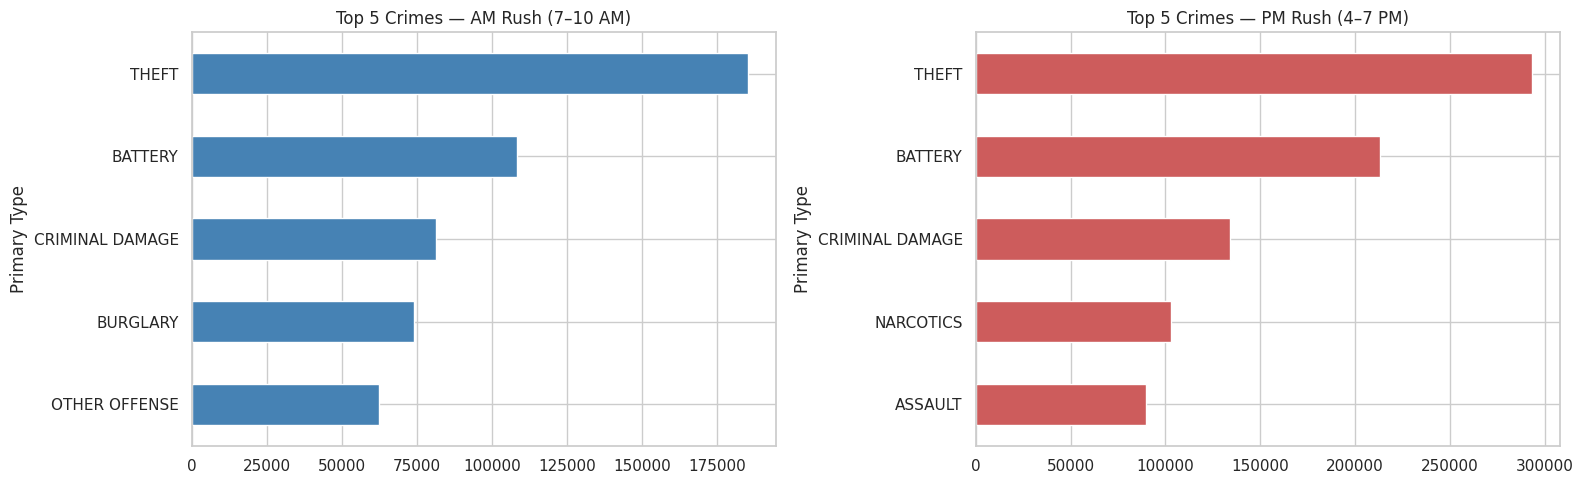

AM Top 5:
 Primary Type
THEFT              185239
BATTERY            108199
CRIMINAL DAMAGE     81281
BURGLARY            73998
OTHER OFFENSE       62453
Name: count, dtype: int64 

PM Top 5:
 Primary Type
THEFT              293513
BATTERY            213002
CRIMINAL DAMAGE    134099
NARCOTICS          103031
ASSAULT             89600
Name: count, dtype: int64


In [29]:
am_top5 = am_rush['Primary Type'].value_counts().head(5)
pm_top5 = pm_rush['Primary Type'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
am_top5.sort_values().plot(kind='barh', ax=axes[0],
    title='Top 5 Crimes — AM Rush (7–10 AM)', color='steelblue')
pm_top5.sort_values().plot(kind='barh', ax=axes[1],
    title='Top 5 Crimes — PM Rush (4–7 PM)', color='indianred')
plt.tight_layout()
plt.show()

print("AM Top 5:\n", am_top5, "\n")
print("PM Top 5:\n", pm_top5)

### Answer (Q1): Top 5 most common crimes in each rush-hour window

**AM Rush (7–10 AM):**
1. Theft — 185,239
2. Battery — 108,199
3. Criminal Damage — 81,281
4. Burglary — 73,998
5. Other Offense — 62,453

**PM Rush (4–7 PM):**
1. Theft — 293,513
2. Battery — 213,002
3. Criminal Damage — 134,099
4. Narcotics — 103,031
5. Assault — 89,600

**Theft, Battery, and Criminal Damage are the top 3 in both windows.**
The difference is in the 4th–5th spots: AM rush features **Burglary** and
**Other Offense**, while PM rush features **Narcotics** and **Assault** —
crimes that skew toward the evening. Every category also has a much higher
count in the PM window, consistent with PM rush having ~57% more total crime.

### Q2: Are Motor Vehicle Thefts more common in AM or PM rush?

Motor Vehicle Theft — AM rush: 41578
Motor Vehicle Theft — PM rush: 53714


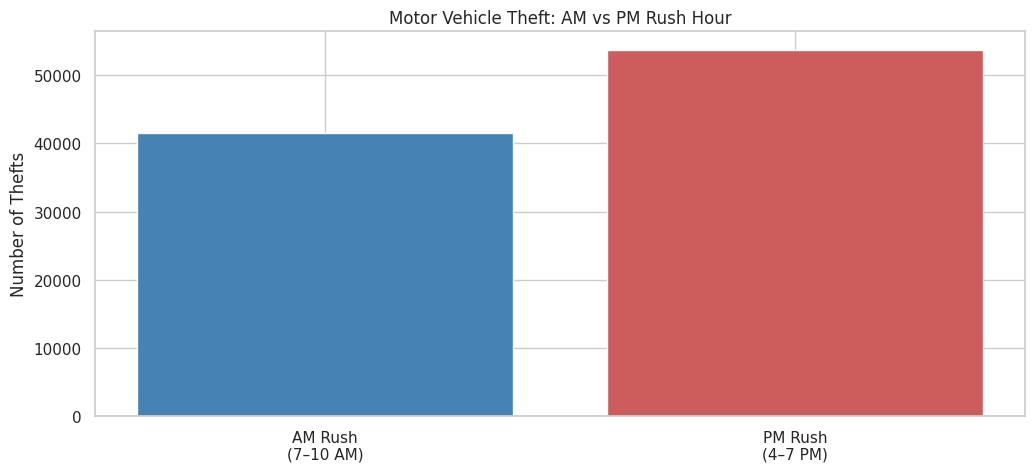

In [30]:
mvt_am = (am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
mvt_pm = (pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()

print("Motor Vehicle Theft — AM rush:", mvt_am)
print("Motor Vehicle Theft — PM rush:", mvt_pm)

plt.bar(['AM Rush\n(7–10 AM)', 'PM Rush\n(4–7 PM)'], [mvt_am, mvt_pm],
        color=['steelblue', 'indianred'])
plt.title('Motor Vehicle Theft: AM vs PM Rush Hour')
plt.ylabel('Number of Thefts')
plt.show()

### Answer (Q2): Are Motor Vehicle Thefts more common in AM or PM rush?

**Motor Vehicle Thefts are more common during PM rush hour (4–7 PM).**

- AM rush (7–10 AM): **41,578** thefts
- PM rush (4–7 PM): **53,714** thefts

PM rush sees about **29% more** motor vehicle thefts than AM rush — consistent
with the overall pattern that crime concentrates more in the late-afternoon/evening
commute than the morning.

# Topic 6 — Seasonality

We use `statsmodels.tsa.seasonal.seasonal_decompose` to break the time series
into **trend + seasonal + residual** components and identify recurring cycles.
We examine two cycles: a **yearly cycle** (monthly data) and a **weekly cycle** (daily data).

### Yearly cycle — monthly resampled data

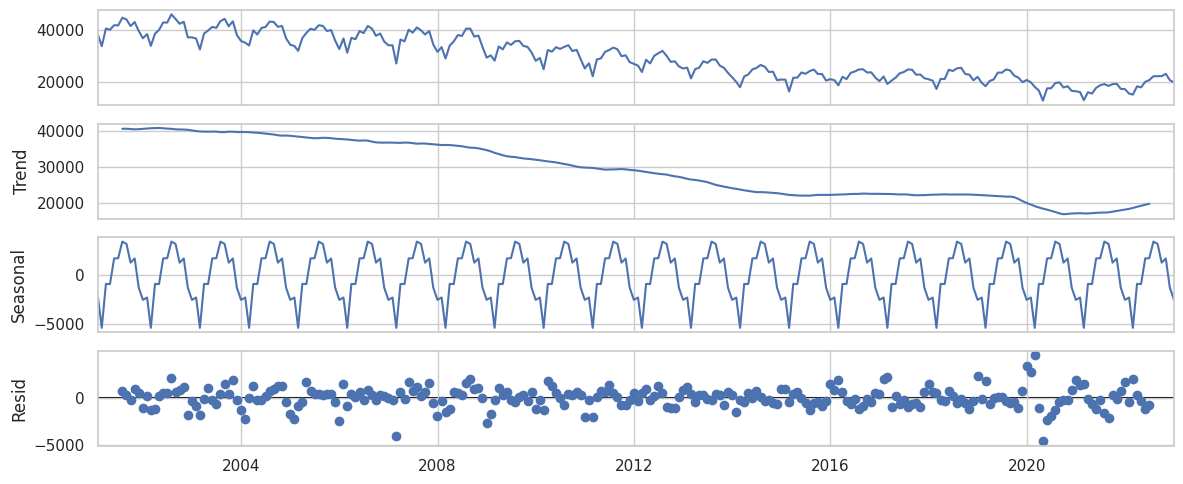

Yearly cycle length: 12 months (1 year)
Magnitude (max - min of seasonal component): 8898


In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Monthly total crimes
monthly = df.resample('ME').size()

result_year = seasonal_decompose(monthly, model='additive', period=12)
result_year.plot()
plt.tight_layout()
plt.show()

seasonal_year = result_year.seasonal
print("Yearly cycle length: 12 months (1 year)")
print("Magnitude (max - min of seasonal component):",
      round(seasonal_year.max() - seasonal_year.min()))

### Answer: Yearly Cycle

The decomposition reveals a clear, repeating **yearly cycle**:

- **Trend** (2nd panel): confirms the long-term decline from ~40,000 to ~20,000
  crimes/month, with the COVID-19 dip around 2020 and a slight rebound after.
- **Seasonal** (3rd panel): a consistent 12-month wave repeats every year —
  crime **peaks in summer** (around July) and **dips in winter** (around February).
- **Residual** (4th panel): mostly small and random, meaning trend + seasonality
  explain most of the variation in the data.

**Cycle length:** 12 months (1 year)
**Magnitude:** ~**8,898** crimes/month between the seasonal low (winter) and
high (summer).

### Weekly cycle — daily data, zoomed in to read the pattern

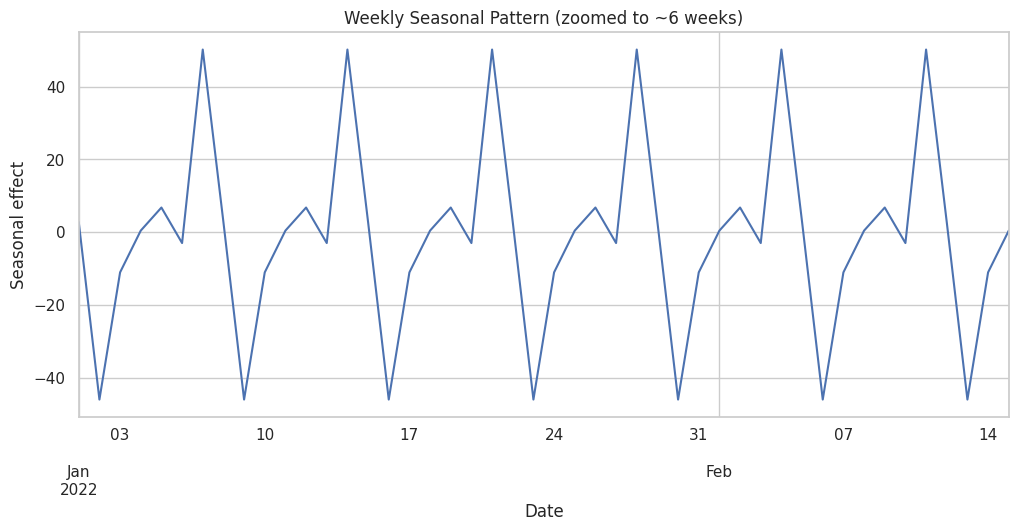

Weekly cycle length: 7 days (1 week)
Magnitude (max - min of seasonal component): 96


In [32]:
result_week = seasonal_decompose(daily_counts, model='additive', period=7)

# Zoom into ~6 weeks so the weekly pattern is readable
result_week.seasonal['2022-01-01':'2022-02-15'].plot(
    title='Weekly Seasonal Pattern (zoomed to ~6 weeks)')
plt.ylabel('Seasonal effect')
plt.show()

seasonal_week = result_week.seasonal
print("Weekly cycle length: 7 days (1 week)")
print("Magnitude (max - min of seasonal component):",
      round(seasonal_week.max() - seasonal_week.min()))

### Answer: Weekly Cycle

The daily data also contains a clear, repeating **weekly cycle** (7-day pattern):

- The seasonal effect swings from about **−45 to +50** crimes/day, repeating
  every 7 days.
- Crime is **highest on weekends (especially Friday/Saturday)** and
  **lowest mid-week (around Sunday/Monday)**.

**Cycle length:** 7 days (1 week)
**Magnitude:** ~**96** crimes/day between the weekly low and high (≈ +50 to −45).

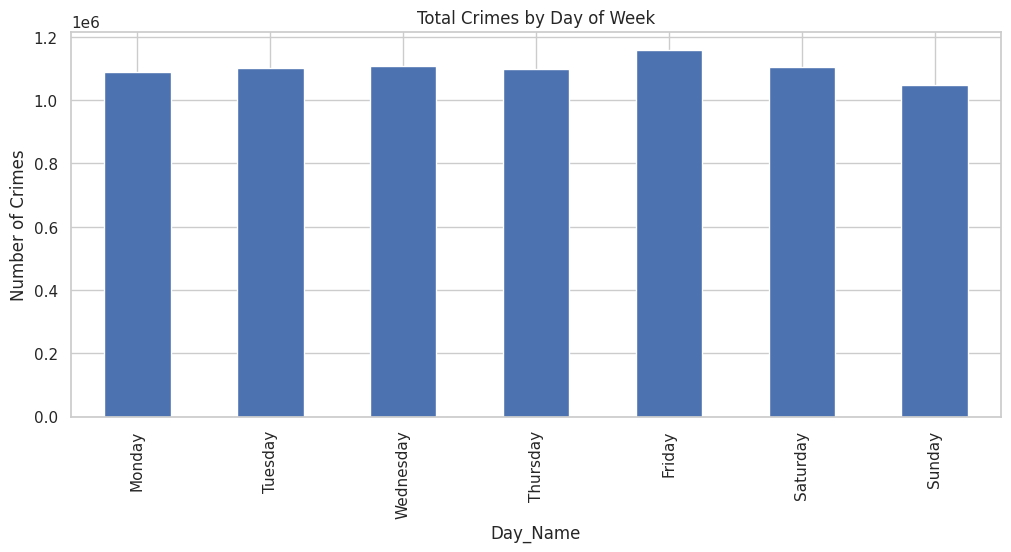

Day with MOST crimes: Friday -> 1159374
Day with LEAST crimes: Sunday -> 1048161


In [33]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day = df['Day_Name'].value_counts().reindex(day_order)

by_day.plot(kind='bar', title='Total Crimes by Day of Week')
plt.ylabel('Number of Crimes')
plt.show()

print("Day with MOST crimes:", by_day.idxmax(), "->", by_day.max())
print("Day with LEAST crimes:", by_day.idxmin(), "->", by_day.min())

### Answer: Weekly Cycle

The daily data contains a clear, repeating **weekly cycle** (7-day pattern),
confirmed by both the seasonal decomposition and the day-of-week totals:

- Crime is **highest on Friday** (1,159,374 total) and **lowest on Sunday**
  (1,048,161 total).
- The seasonal effect repeats every 7 days, swinging by ~96 crimes/day across the week.

**Cycle length:** 7 days (1 week)
**Magnitude:** ~96 crimes/day between the weekly low (Sunday) and high (Friday).